In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy
import pickle 
import ast
from collections.abc import Iterable
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

#import the modules for analyzing the results of the k-path search
from Path_Analytics import *
import glob
import os
from tqdm import tqdm

In [6]:
with open('../data_and_models/algo_times.csv', 'r') as f:
    algo_times = pd.read_csv(f, index_col=0)

In [7]:
algo_times

,time,k,n_steps,strategy,n_paths
0,83.40,20.0,5,k_path_beam,NaN
1,195.20,40.0,5,k_path_beam,NaN
2,263.76,60.0,5,k_path_beam,NaN
3,267.34,80.0,5,k_path_beam,NaN
4,345.28,100.0,5,k_path_beam,NaN
5,380.57,120.0,5,k_path_beam,NaN
6,401.07,140.0,5,k_path_beam,NaN
7,448.07,160.0,5,k_path_beam,NaN
8,485.15,180.0,5,k_path_beam,NaN
9,503.68,190.0,5,k_path_beam,NaN


Goal: Create a set of analytics functions for the output of identified paths 
-
0) create a binary matrix of rows of paths and columns of drugs 
1) Distribution of drugs in each successful path across all conversions
2) Total number of successful paths for each conversion 
3) Unsupervised clustering for each conversion 
    - redundancy - total paths for each cluster 
    - uniqueness - total number of clusters per conversion 

#implement nearest neighbor and TSNE and UMAP

Jaccard Distance Threshold with Heirarchical clustering
-
option: Try different similarity parameters to ensure robust clustering

Meaning:
- 0.1 - 0.3 = Only paths with almost identical drug sets merge.
- 0.4 - 0.6 = Paths must share a fair proportion of drugs; moderate strictness
- 0.7 - 0.9 = Paths that share just a handful of drugs can end up together; coarse granularity
- 0.9 - 1.0 = Nearly everything collapses into one cluster (unless totally disjoint)

# Analysis

In [5]:
#read in the pickle file 
with open('../data_and_models/search_results_beam_k80_n5.pkl', 'rb') as f:
    df = pickle.load(f) 
print(df['covered_threshold'].value_counts())
#filter down to only those that were successful
df = df[df['covered_threshold']==True].copy()
#df['path'] = df['drug_sequence']

covered_threshold
False    11047
True      8307
Name: count, dtype: int64


In [3]:
df['percent_complete'] = (df['starting_distance'] - df['final_distance'])/ df['starting_distance']
df['percent_complete'].describe()

count    8307.000000
mean        0.545433
std         0.030042
min         0.500005
25%         0.520685
50%         0.541766
75%         0.564234
max         0.635546
Name: percent_complete, dtype: float64

In [4]:
df

,search_id,type_of_search,n_steps,k,n_paths,beta,blend,threshold,starting_cl,target_cl,...,path_type,is_best_at_step,is_success,covered_threshold,end_position,drug_sequence,genes_targeted,cell_path,final_distance,path
62,7,k_path_beam,5,80,None,None,2,0.5,CVCL_0023,CVCL_0292,...,threshold,True,False,True,"[-0.9505828226880422, 0.38036970228210804, 1.1...","[[('TAK-733', 5.0, 'uM')], [('Hesperidin', 5.0...","[(map2k2, map2k1), (cacna1b,), (jak3, tyk2, ja...","[[CVCL_0023, None], [CVCL_0023, None], [CVCL_0...",3.421822,"[[('TAK-733', 5.0, 'uM')], [('Hesperidin', 5.0..."
63,7,k_path_beam,5,80,None,None,2,0.5,CVCL_0023,CVCL_0292,...,threshold,False,False,True,"[-0.9505828226880422, 0.38036970228210804, 1.1...","[[('Hesperidin', 5.0, 'uM')], [('TAK-733', 5.0...","[(cacna1b,), (map2k2, map2k1), (jak3, tyk2, ja...","[[CVCL_0023, None], [CVCL_0023, None], [CVCL_0...",3.421822,"[[('Hesperidin', 5.0, 'uM')], [('TAK-733', 5.0..."
64,7,k_path_beam,5,80,None,None,2,0.5,CVCL_0023,CVCL_0292,...,threshold,False,False,True,"[-0.9431643632156405, 0.3810516733600844, 1.18...","[[('TAK-733', 5.0, 'uM')], [('Hesperidin', 5.0...","[(map2k2, map2k1), (cacna1b,), (cnr1,), (jak3,...","[[CVCL_0023, None], [CVCL_0023, None], [CVCL_0...",3.425957,"[[('TAK-733', 5.0, 'uM')], [('Hesperidin', 5.0..."
65,7,k_path_beam,5,80,None,None,2,0.5,CVCL_0023,CVCL_0292,...,threshold,False,False,True,"[-0.9431643632156405, 0.3810516733600844, 1.18...","[[('Hesperidin', 5.0, 'uM')], [('TAK-733', 5.0...","[(cacna1b,), (map2k2, map2k1), (cnr1,), (jak3,...","[[CVCL_0023, None], [CVCL_0023, None], [CVCL_0...",3.425957,"[[('Hesperidin', 5.0, 'uM')], [('TAK-733', 5.0..."
66,7,k_path_beam,5,80,None,None,2,0.5,CVCL_0023,CVCL_0292,...,threshold,False,False,True,"[-0.8208508996036671, 0.37914291829712127, 1.3...","[[('Abemaciclib', 5.0, 'uM')], [('Capmatinib',...","[(cdk4, cdk6), (met,), (pgr, nr3c2, ar), (gnrh...","[[CVCL_0023, None], [None, CVCL_0023], [CVCL_0...",3.427031,"[[('Abemaciclib', 5.0, 'uM')], [('Capmatinib',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19338,2252,k_path_beam,5,80,None,None,2,0.5,CVCL_C466,CVCL_1716,...,threshold,False,False,True,"[0.789319004714883, 0.8105273886725401, 0.1780...","[[('Regorafenib', 5.0, 'uM')], [('vincristine'...","[(pdgfra, ddr2, flt4, kit, frk, abl1, fgfr1, r...","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",3.200092,"[[('Regorafenib', 5.0, 'uM')], [('vincristine'..."
19339,2252,k_path_beam,5,80,None,None,2,0.5,CVCL_C466,CVCL_1716,...,threshold,False,False,True,"[0.08736386394786105, 0.4083325697206059, 0.52...","[[('Vemurafenib', 5.0, 'uM')], [('venetoclax',...","[(braf,), (bcl2,), (gnrhr,), (cnr1,), (adra2b,...","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",3.213078,"[[('Vemurafenib', 5.0, 'uM')], [('venetoclax',..."
19340,2252,k_path_beam,5,80,None,None,2,0.5,CVCL_C466,CVCL_1716,...,threshold,False,False,True,"[0.08881677014687611, 0.4081919981423732, 0.52...","[[('Vemurafenib', 5.0, 'uM')], [('venetoclax',...","[(braf,), (bcl2,), (cnr1,), (gnrhr,), (adra2b,...","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",3.213516,"[[('Vemurafenib', 5.0, 'uM')], [('venetoclax',..."
19341,2252,k_path_beam,5,80,None,None,2,0.5,CVCL_C466,CVCL_1716,...,threshold,False,False,True,"[0.15660534464560727, 0.4697558251520088, 0.50...","[[('Vemurafenib', 5.0, 'uM')], [('venetoclax',...","[(braf,), (bcl2,), (gnrhr,), (cnr1,), (adrb1,)]","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",3.216296,"[[('Vemurafenib', 5.0, 'uM')], [('venetoclax',..."


/Users/carloruggeri/Documents/Git/RL_single_cell/analysis/Path_Analytics.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


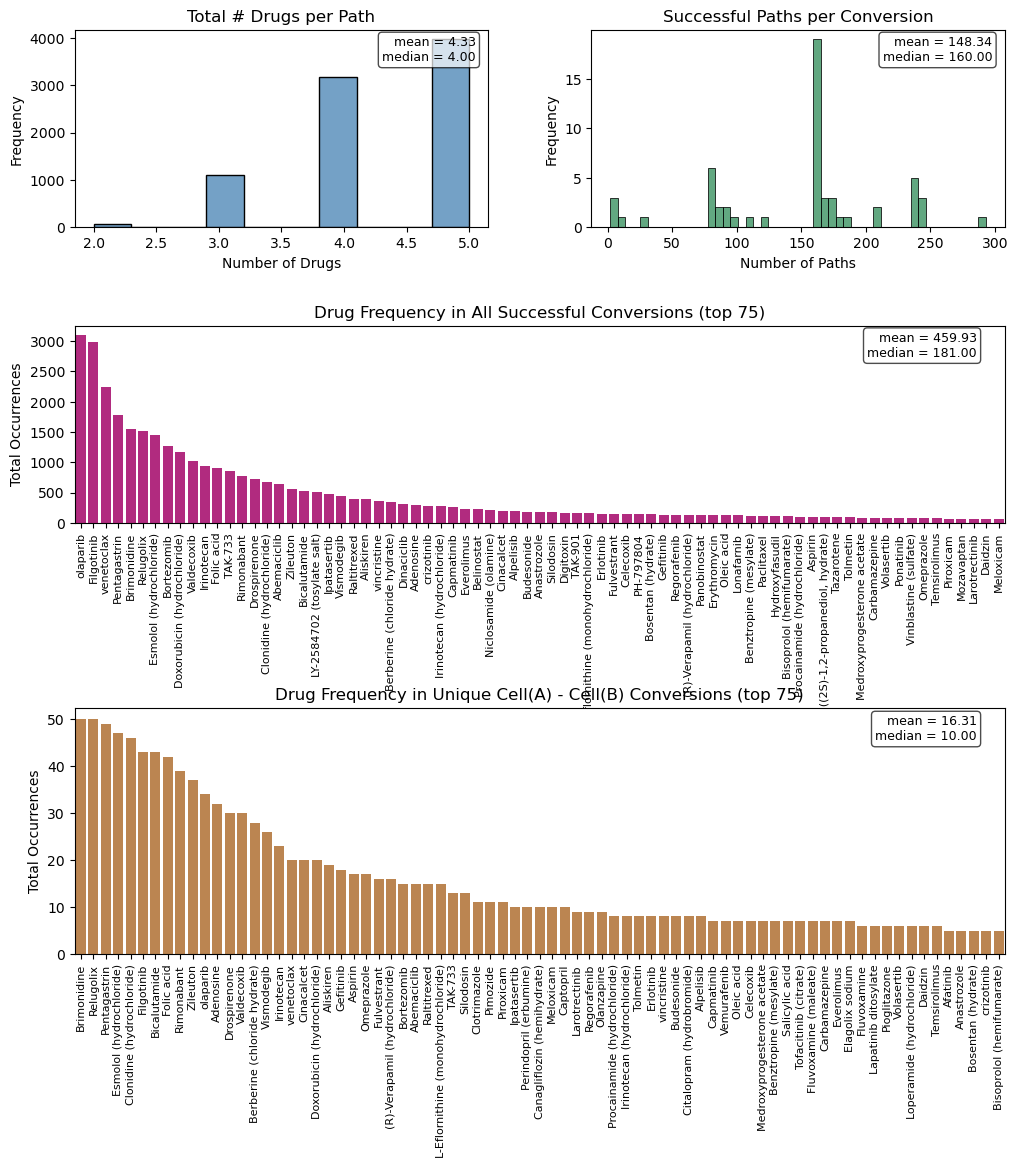

In [4]:
#plot initial QC for the drug matrix - global metrics
drug_matrix = build_conversion_drug_matrix(df)
fig, axes = plot_path_and_conversion_stats(drug_matrix, 
                                    figsize=(12,12), 
                                    bins_drugs=10, 
                                    bins_conv=50,
                                    top_n=75,
                                    show=True)

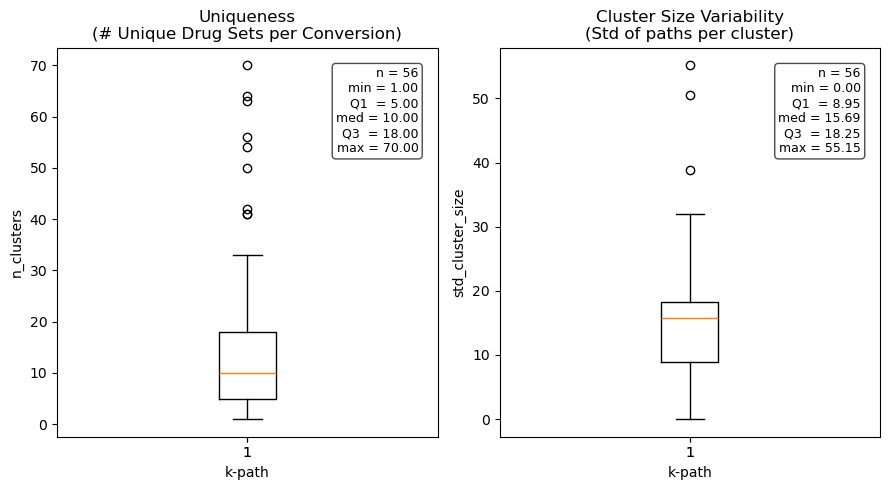

In [5]:
#now we can unsupervised cluster the conversions based on the drug matrix 
summary, detailed = cluster_all_conversions(
    drug_matrix,
    metric="jaccard",
    distance_threshold=0.5,
)

#plot the summary of the clustering results
fig, axes = plot_cluster_summary(
    summary,
    x_label="k-path",
    figsize=(9, 5),
    show=True
)

# Inside algorithms scaling analysis

Analyzing files: 100%|██████████| 6/6 [05:32<00:00, 55.47s/it] 


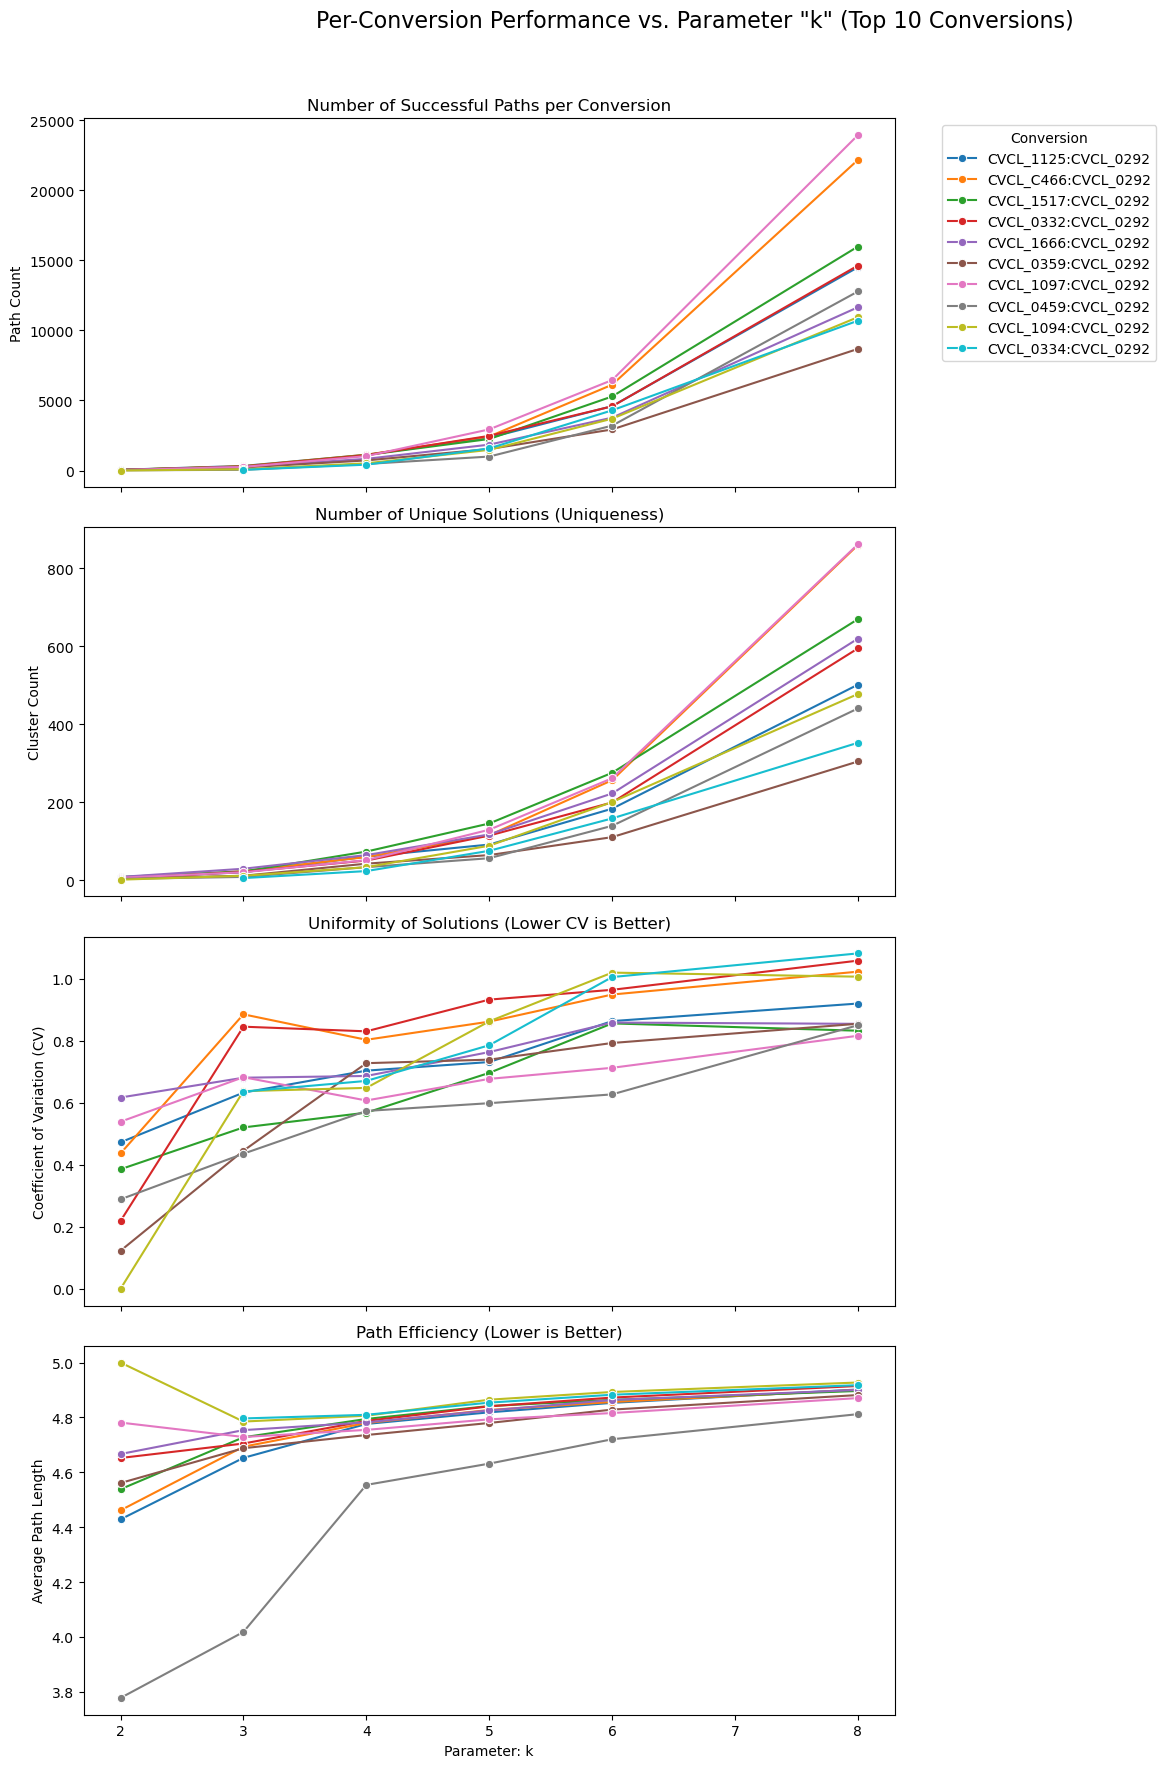

In [2]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/search_results_tree_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary, fig, axes = plot_per_conversion_trends(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex,
        top_n=10 # You can adjust how many top conversions to show
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

the more you search the less uniformity across clusters you get, the more you run it the more paths and clusters you get but these clusters become less uniform suggesting that even after running this not for too much we already get some sort of conversion to specific clusters. Makes sense from a biological pow (you would expect that to convert between one cell and another the actual conversion set is small). Further analysis could be: take one conversion (say the green one), consider top 10 cluster and plot over parameter the absolute number of paths per each cluster to then get to the conclusion to the decision of applying a drug set from a specific cluster. Also another thing I could do is to take one specific conversion and show that as we increase threhold we get less clusters and less uniform clusters (might not be true the last point)

Analyzing files: 100%|██████████| 10/10 [00:29<00:00,  2.99s/it]


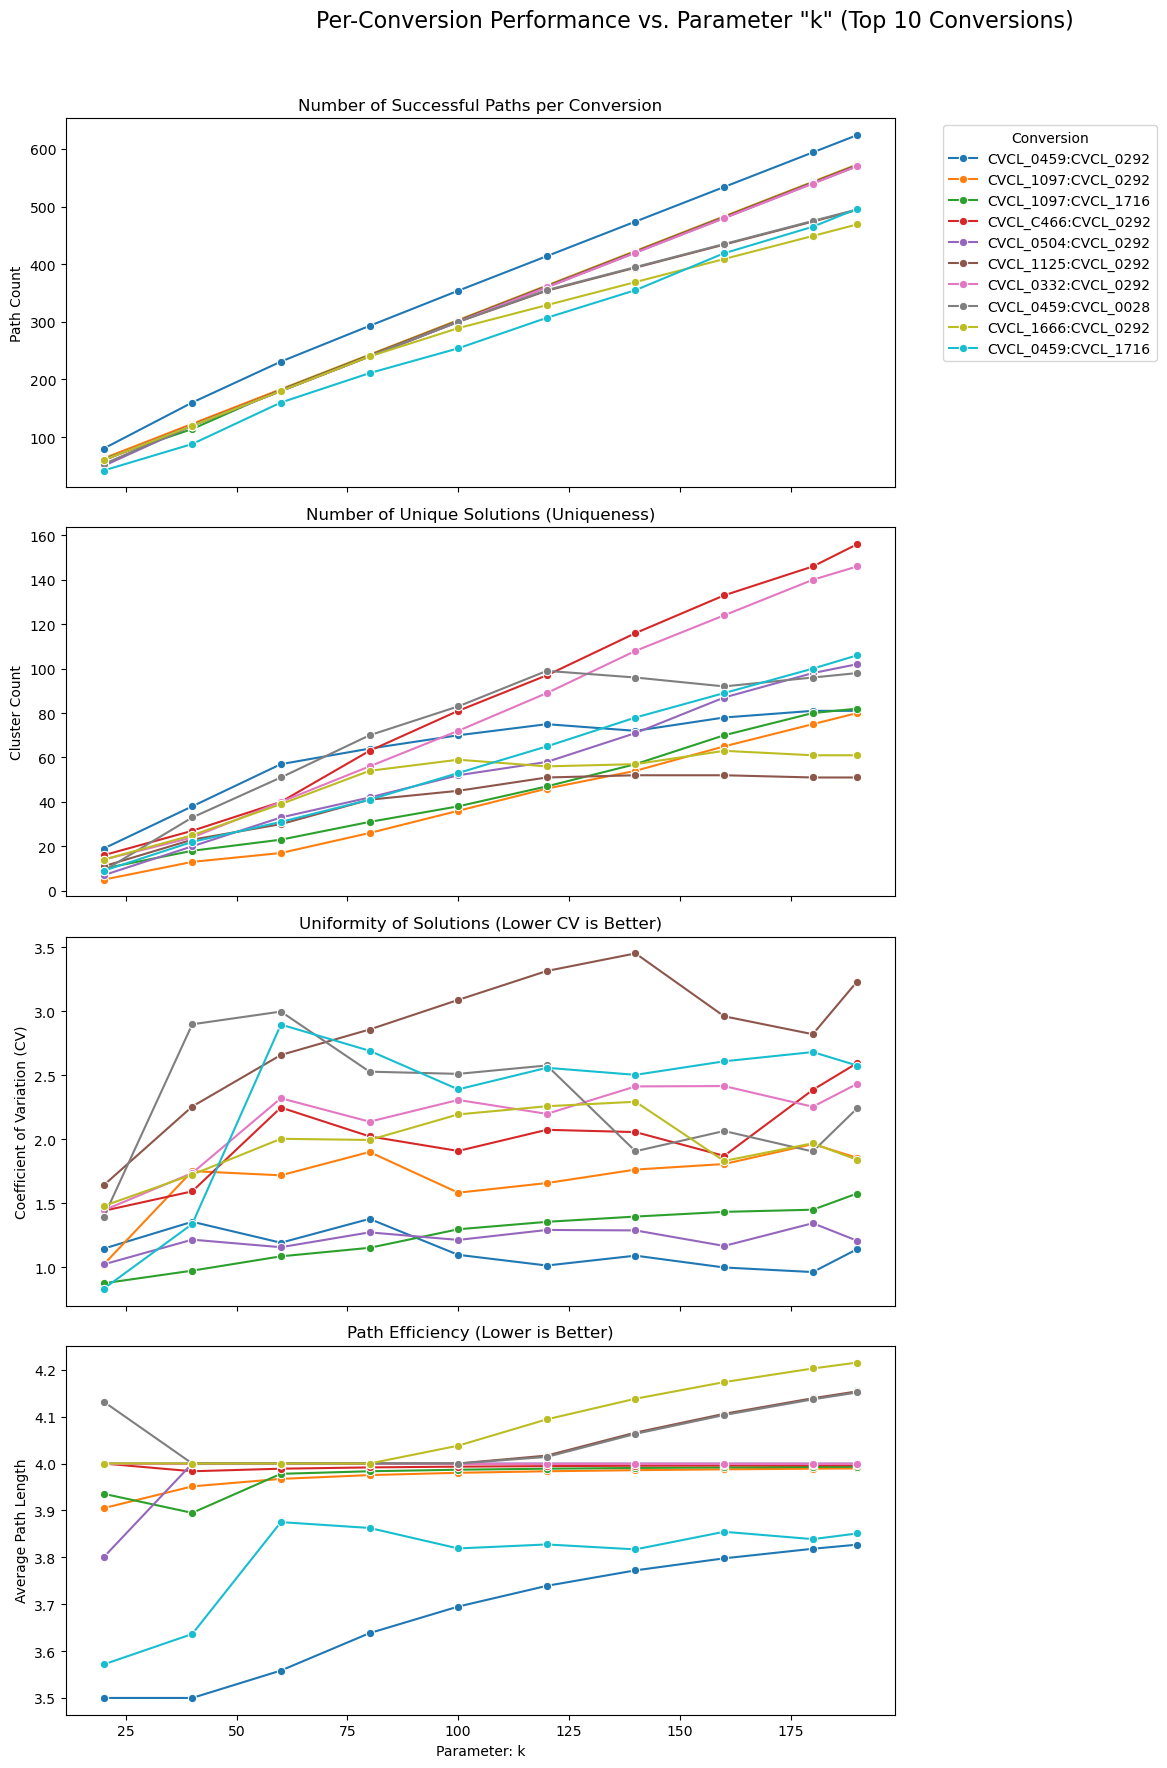

In [3]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/search_results_beam_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary, fig, axes = plot_per_conversion_trends(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex,
        top_n=10 # You can adjust how many top conversions to show
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Analyzing files: 100%|██████████| 6/6 [00:00<00:00,  8.11it/s]


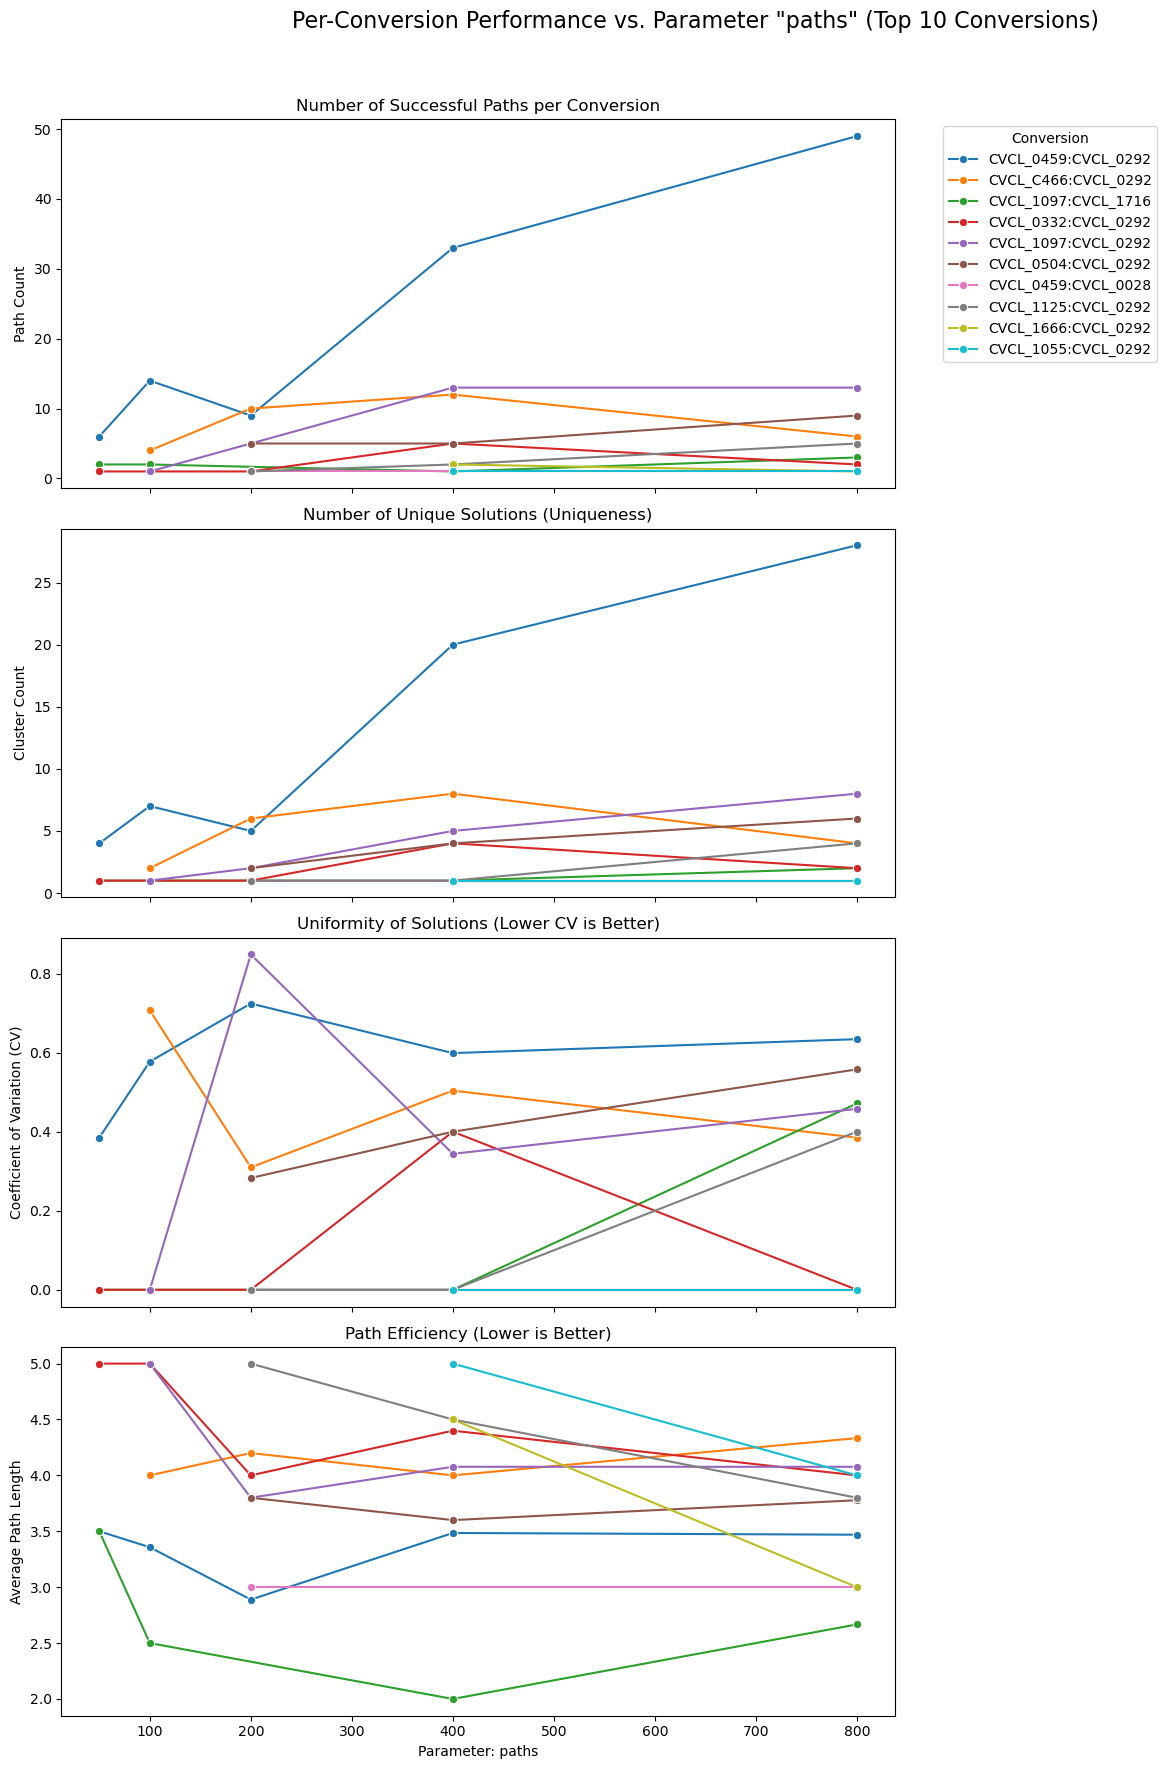

In [4]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/probabilistic_search_results_paths*_steps5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'paths'
param_regex = r'_paths(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    results_summary, fig, axes = plot_per_conversion_trends(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex,
        top_n=10 # You can adjust how many top conversions to show
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Analyzing files: 100%|██████████| 6/6 [05:27<00:00, 54.53s/it] 


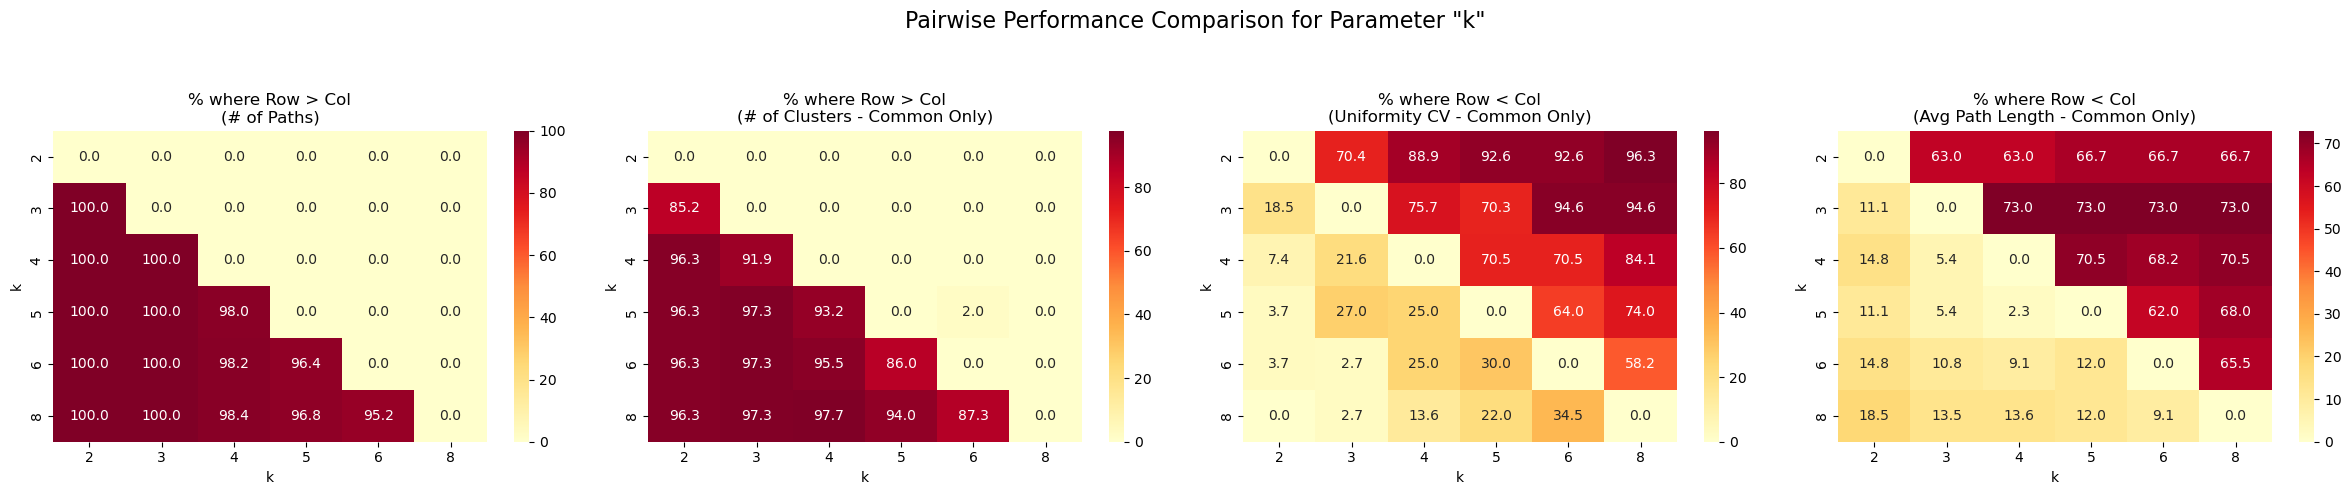

In [5]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/search_results_tree_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    fig, axes = plot_pairwise_parameter_comparison(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Analyzing files: 100%|██████████| 10/10 [00:29<00:00,  2.96s/it]


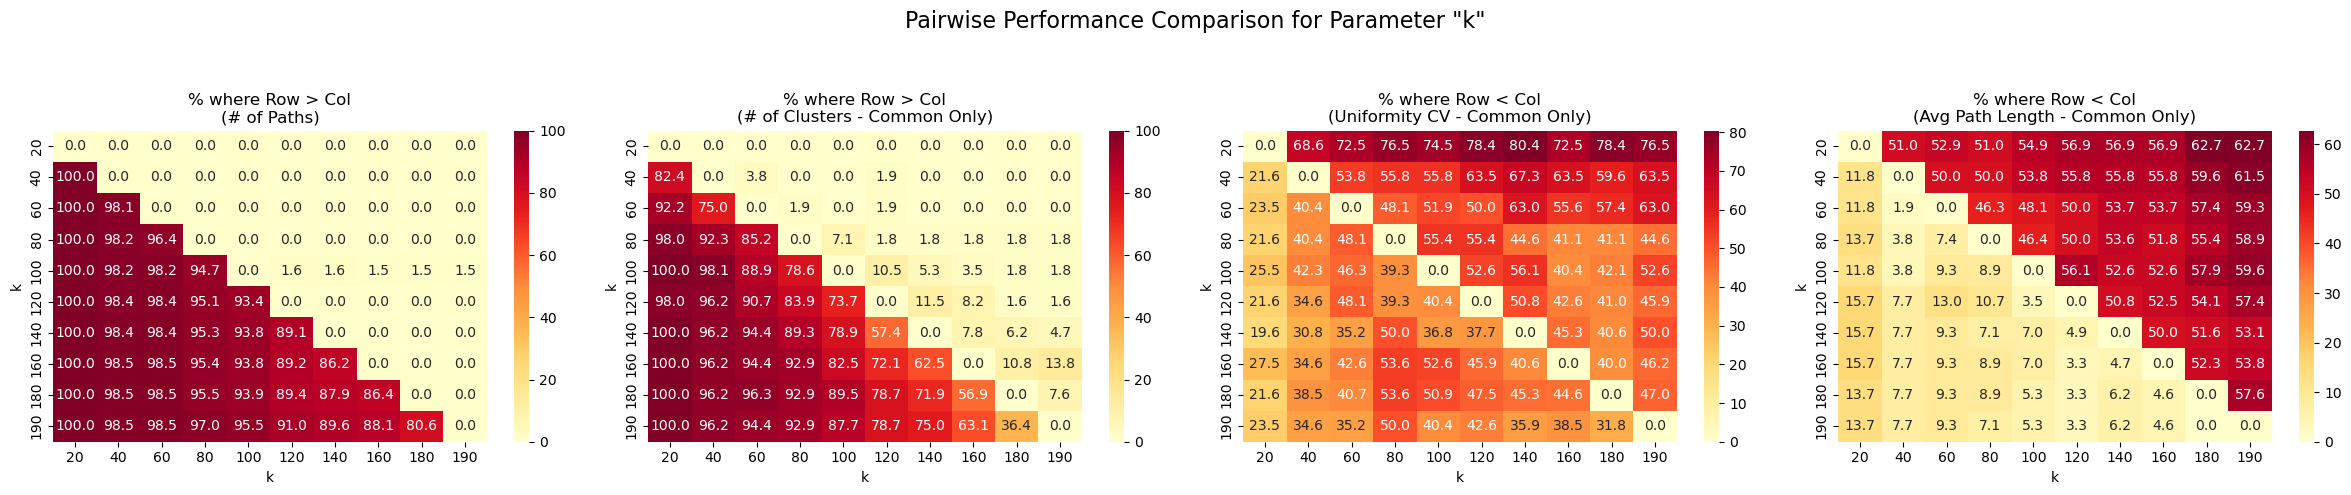

In [6]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/search_results_beam_k*_n5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'k'
param_regex = r'_k(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    fig, axes = plot_pairwise_parameter_comparison(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

Analyzing files: 100%|██████████| 6/6 [00:00<00:00,  8.50it/s]


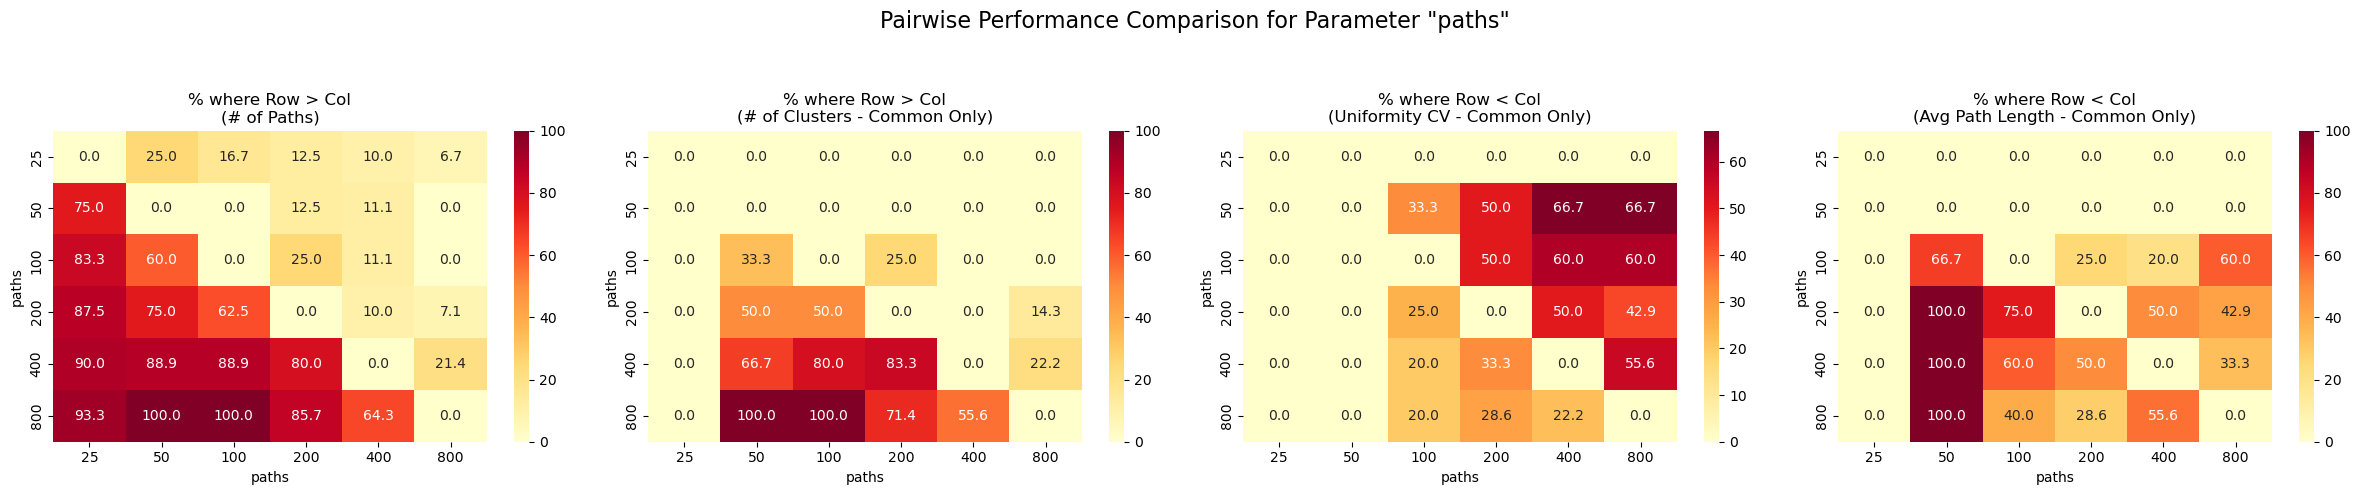

In [7]:
# This assumes the files are in the current directory.
# If they are in a subdirectory, add the path (e.g., 'data_and_models/search_*')
file_pattern = '../data_and_models/probabilistic_search_results_paths*_steps5.pkl'
files_to_analyze = glob.glob(file_pattern)

# --- 2. Define the parameter name and the regex ---
# The parameter you varied is 'k'.
# The regex r'_k(\d+)_' finds the number between '_k' and '_'.
param_name = 'paths'
param_regex = r'_paths(\d+)_'

# --- 3. Run the analysis ---
if files_to_analyze:
    fig, axes = plot_pairwise_parameter_comparison(
        file_paths=files_to_analyze,
        param_name=param_name,
        param_regex=param_regex
    )
else:
    print(f"No files found matching the pattern: {file_pattern}")

# Across algorithms performance analysis

Calculating metrics: 100%|██████████| 22/22 [05:59<00:00, 16.35s/it]


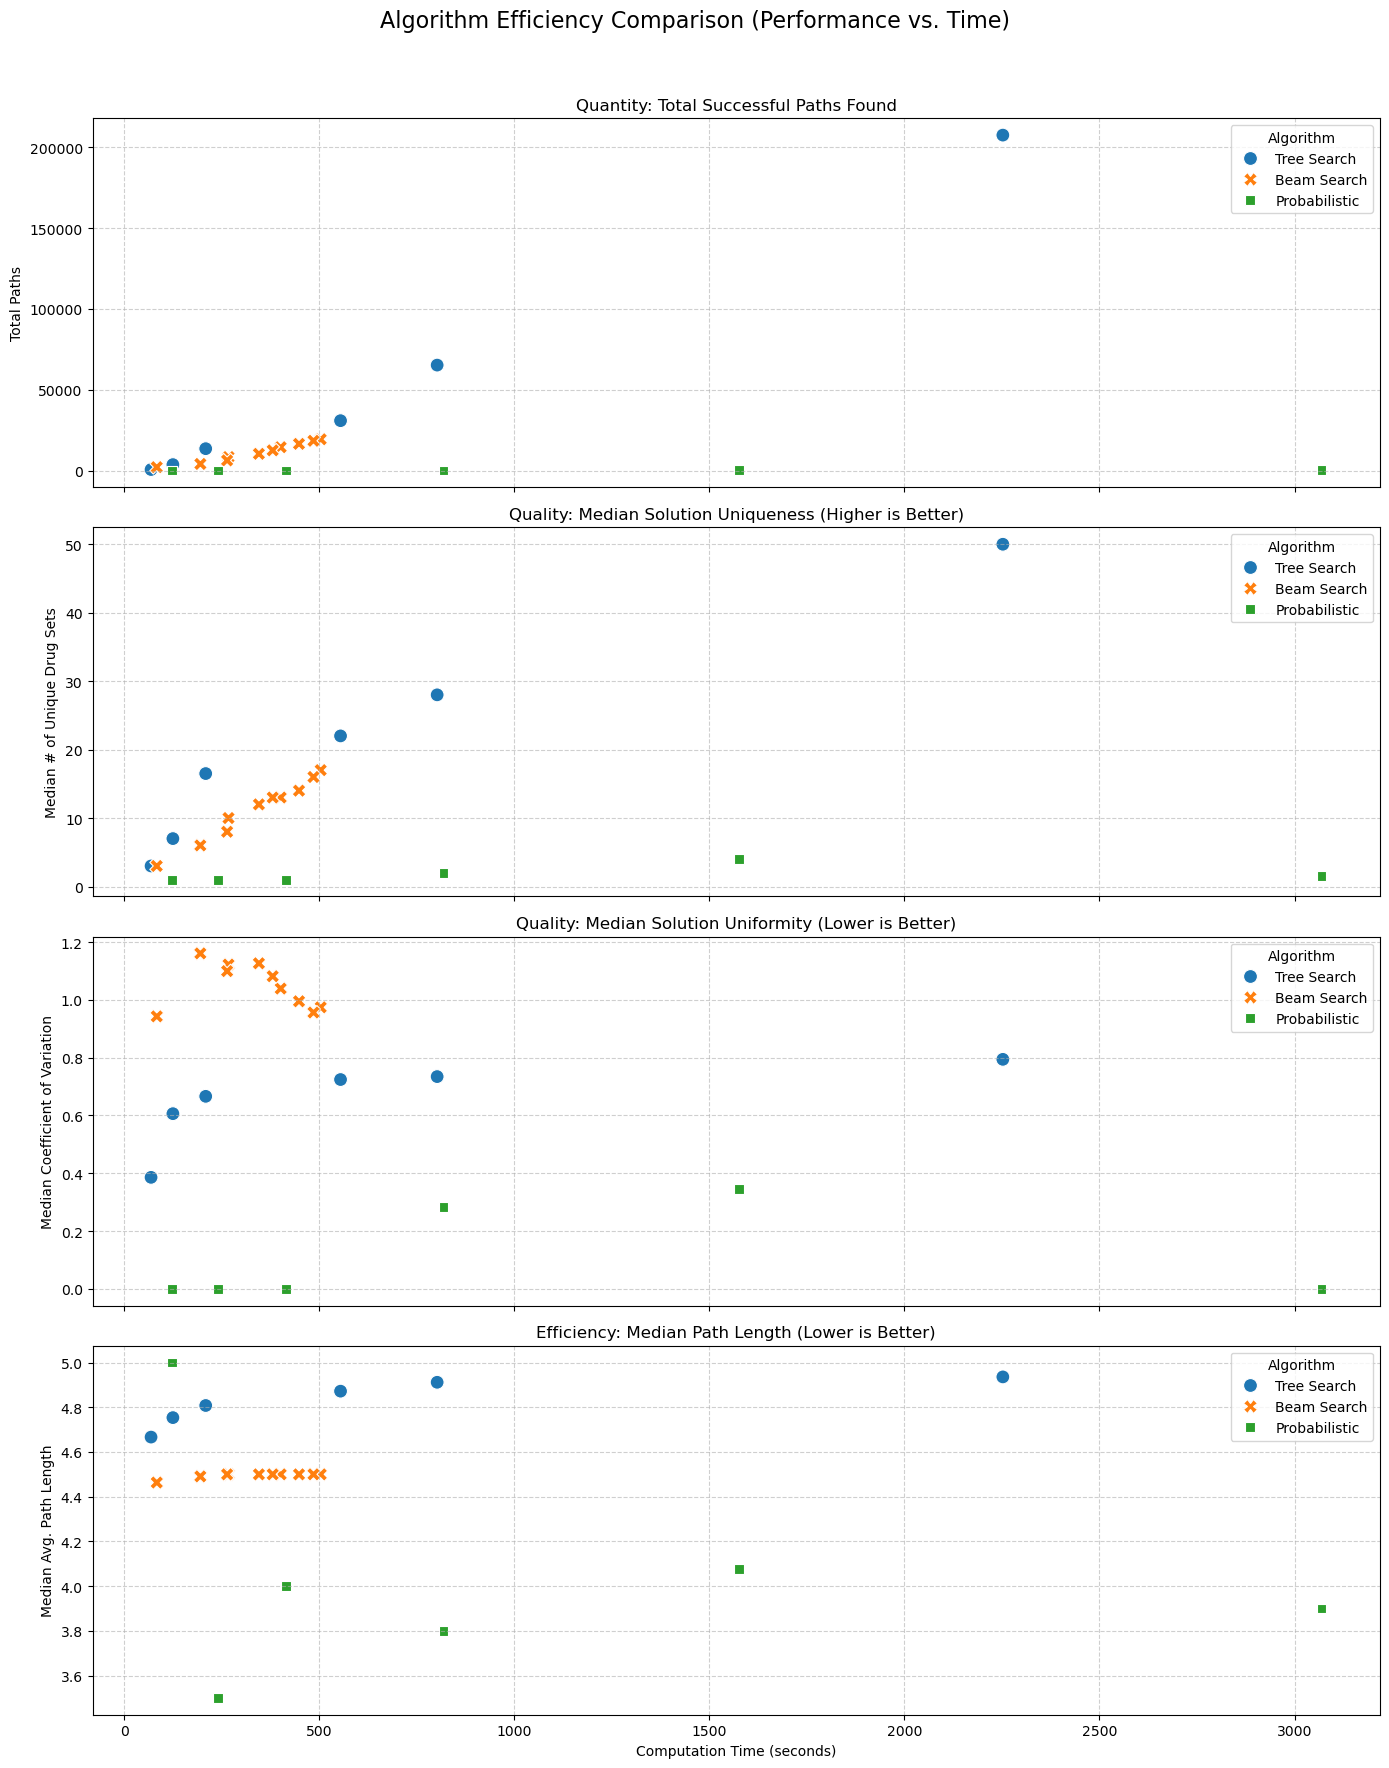

In [8]:
# --- 1. Define the directory where your results are stored ---
results_dir = '../data_and_models/'

# --- 2. Create specific patterns for each algorithm and find the files ---
tree_files = glob.glob(os.path.join(results_dir, 'search_results_tree_k*.pkl'))
beam_files = glob.glob(os.path.join(results_dir, 'search_results_beam_k*.pkl'))
prob_files = glob.glob(os.path.join(results_dir, 'probabilistic_search_results_paths*.pkl'))

# --- 3. Combine the lists into one ---
all_files_to_analyze = tree_files + beam_files + prob_files

# --- 4. Define the path to your timing data ---
times_csv = os.path.join(results_dir, 'algo_times.csv')

# --- 5. Run the comparison analysis ---
if all_files_to_analyze:
    comparison_results, fig, axes = plot_algorithm_efficiency(
        file_paths=all_files_to_analyze,
        times_csv_path=times_csv
    )
else:
    print("No matching result files were found. Check your file patterns.")